In [53]:
from random import random
import torch
import numpy as np
import matplotlib.pyplot as plt

# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

import gym
env = gym.make("CartPole-v1")
observation, info = env.reset(seed=42)

print("environment action space", env.action_space)

numBins = 20
bins = np.array([
    np.linspace(-4.81, 4.81, numBins), # cart position
    np.linspace(-4, 4, numBins),   # cart velocity
    np.linspace(-0.418, 0.418, numBins),    # pole angle
    np.linspace(-4, 4, numBins),    # angular velocity
    ])
Q_table = np.random.rand(numBins, numBins, numBins, numBins, 2)

def discretize(observation):
    state = []
    for i in range(len(observation)):
        state.append(np.digitize(observation[i], bins[i]))
    return state

state = discretize(observation)

print('Q_current', Q_table[state[0]][state[1]][state[2]][state[3]])

def policy(state): # Defining policy - takes in state and returns action
    p = random()
    if p > epsilon:
        return np.argmax(Q_table[state[0]][state[1]][state[2]][state[3]])
    else:
        return env.action_space.sample()

episode_rewards = []
episode_reward = 0
learning_rate = 0.15
discount = 0.95
epsilon = 0.90


Using cuda device
environment action space Discrete(2)
Q_current [0.3379405 0.187318 ]


In [54]:
# Iterating 2
episode = 0
while episode < 10000:
    action = policy(state)
    #print('Q_table', Q_table[state[0]][state[1]][state[2]][state[3]])
    Q_old = Q_table[state[0]][state[1]][state[2]][state[3]][action]
    #print('Action', action)
    #print('Q_old', Q_old)
    # New step
    observation, reward, terminated, truncated, info = env.step(action)
 
    new_state = discretize(observation)
    #print('state', state)
    new_action = policy(new_state)
    episode_reward += reward
    #print("Ovservation:", observation, "\nReward:", reward, "\nAction:", action)
    
    Q_table[state[0]][state[1]][state[2]][state[3]][action] = (1-learning_rate)*Q_old + learning_rate*(reward + discount*np.max(Q_table[new_state[0]][new_state[1]][new_state[2]][new_state[3]]))
    state = new_state

    if terminated or truncated:
        observation, info = env.reset()
        state = discretize(observation)
        print('episode_reward:', episode_reward,'\nEpsilon', epsilon, '\nepisode:', episode, '\n')
        epsilon = max(1-episode_reward/150,0.01)
        episode_rewards.append(episode_reward)
        episode_reward = 0
        episode += 1

env.close()

episode_reward: 16.0 
Epsilon 0.9 
episode: 0 

episode_reward: 10.0 
Epsilon 0.8933333333333333 
episode: 1 

episode_reward: 26.0 
Epsilon 0.9333333333333333 
episode: 2 

episode_reward: 21.0 
Epsilon 0.8266666666666667 
episode: 3 

episode_reward: 30.0 
Epsilon 0.86 
episode: 4 

episode_reward: 55.0 
Epsilon 0.8 
episode: 5 

episode_reward: 23.0 
Epsilon 0.6333333333333333 
episode: 6 

episode_reward: 28.0 
Epsilon 0.8466666666666667 
episode: 7 

episode_reward: 17.0 
Epsilon 0.8133333333333334 
episode: 8 

episode_reward: 13.0 
Epsilon 0.8866666666666667 
episode: 9 

episode_reward: 16.0 
Epsilon 0.9133333333333333 
episode: 10 

episode_reward: 17.0 
Epsilon 0.8933333333333333 
episode: 11 

episode_reward: 15.0 
Epsilon 0.8866666666666667 
episode: 12 

episode_reward: 21.0 
Epsilon 0.9 
episode: 13 

episode_reward: 25.0 
Epsilon 0.86 
episode: 14 

episode_reward: 10.0 
Epsilon 0.8333333333333334 
episode: 15 

episode_reward: 26.0 
Epsilon 0.9333333333333333 
episode: 

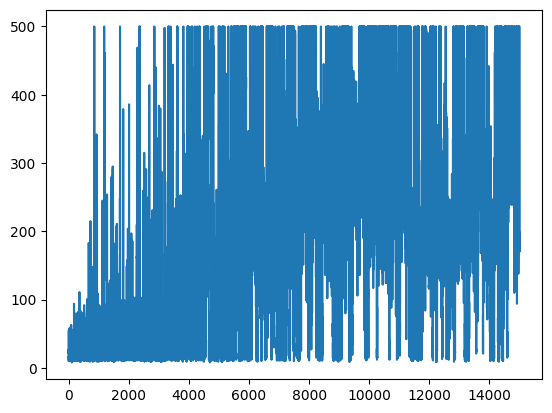

In [56]:
# Plotting learning curve
x = np.linspace(0, len(episode_rewards), len(episode_rewards))
plt.plot(x, episode_rewards)


In [52]:
print('Average length of last 1000 episodes:', np.average(np.array(episode_rewards[(len(episode_rewards)-1000):])))
print(episode_rewards[(len(episode_rewards)-1000):])

Average length of last 1000 episodes: 321.584
[321.0, 273.0, 268.0, 500.0, 128.0, 262.0, 278.0, 500.0, 315.0, 500.0, 321.0, 271.0, 500.0, 500.0, 237.0, 500.0, 332.0, 442.0, 233.0, 155.0, 327.0, 485.0, 500.0, 447.0, 500.0, 365.0, 343.0, 353.0, 323.0, 500.0, 347.0, 500.0, 363.0, 339.0, 500.0, 500.0, 311.0, 313.0, 500.0, 340.0, 337.0, 372.0, 359.0, 393.0, 500.0, 356.0, 318.0, 401.0, 287.0, 340.0, 309.0, 258.0, 321.0, 356.0, 414.0, 500.0, 288.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 321.0, 177.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 488.0, 381.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 498.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 5

In [50]:


x =np.linspace(1, 100, 100)
print(x[90:])

[ 91.  92.  93.  94.  95.  96.  97.  98.  99. 100.]
